<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/Main_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the Heart Disease Dataset

In [116]:
#!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [142]:
import pandas as pd

base_path = "/content/drive/MyDrive/datasets/heart_disease/"
df = pd.read_csv(base_path+"heart_disease.csv")
print(df.head(10))

target_col = "Heart Disease Status"

    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   
5  25.0    Male           152.0              257.0             Low     Yes   
6  78.0  Female           121.0              175.0            High     Yes   
7  38.0  Female           161.0              187.0             Low     Yes   
8  56.0  Female           135.0              291.0             Low      No   
9  75.0    Male           144.0              252.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   

In [143]:
print(df.shape)
print(df.columns)

(10000, 21)
Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')


In [144]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=7)

In [145]:
print(len(train), len(test))

# Check overlap
overlap = train.merge(test, how="inner")
print(len(overlap))

8000 2000
0


In [146]:
train.head(10)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
4989,24.0,Female,170.0,274.0,Medium,No,Yes,No,31.340654,Yes,...,No,Low,High,5.429620,Low,250.0,150.0,3.205021,19.065718,No
4498,25.0,Female,132.0,232.0,Low,No,Yes,No,26.885455,Yes,...,No,NaN,Medium,5.286217,Medium,136.0,131.0,7.669093,19.825244,No
8876,28.0,Male,165.0,163.0,Low,No,No,No,20.731617,Yes,...,No,Medium,Medium,6.247193,Medium,120.0,152.0,10.646891,9.730829,Yes
670,79.0,Female,157.0,282.0,NaN,Yes,No,Yes,28.551388,Yes,...,Yes,Medium,Medium,9.459201,Low,214.0,155.0,9.419200,16.836346,No
9552,33.0,Female,143.0,272.0,Low,Yes,Yes,Yes,35.006275,No,...,Yes,Medium,Low,7.622179,Low,126.0,115.0,10.424272,18.001114,Yes
1757,33.0,Male,170.0,249.0,High,No,No,Yes,27.510316,Yes,...,Yes,NaN,Medium,5.450039,High,303.0,143.0,9.072500,8.534529,No
1781,35.0,Female,139.0,161.0,High,Yes,No,No,24.444616,Yes,...,No,High,Medium,9.669654,Medium,323.0,96.0,7.595638,18.590045,No
5270,52.0,Male,167.0,273.0,Low,No,Yes,Yes,34.306303,Yes,...,No,Low,High,5.966211,Low,295.0,127.0,8.204739,5.658673,No
8130,49.0,Female,175.0,197.0,Low,Yes,Yes,No,19.488652,No,...,Yes,Low,Low,4.468807,Medium,294.0,146.0,1.176243,6.261519,Yes
4426,20.0,Female,155.0,219.0,High,No,Yes,Yes,26.433060,Yes,...,No,High,Low,8.593607,Medium,303.0,135.0,1.011613,8.968104,No


In [155]:
df_corr = pd.get_dummies(df).drop(columns=[target_col], errors='ignore')

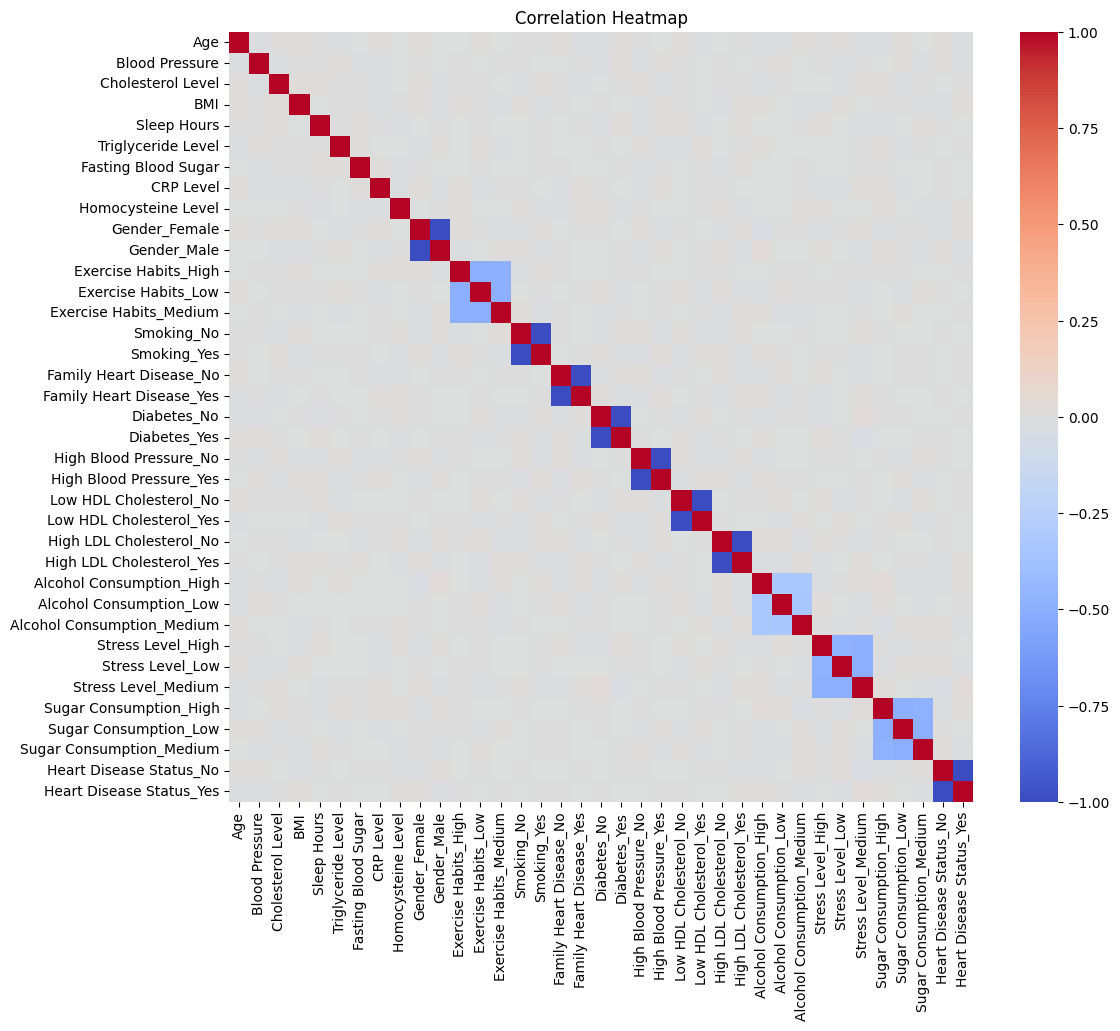

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

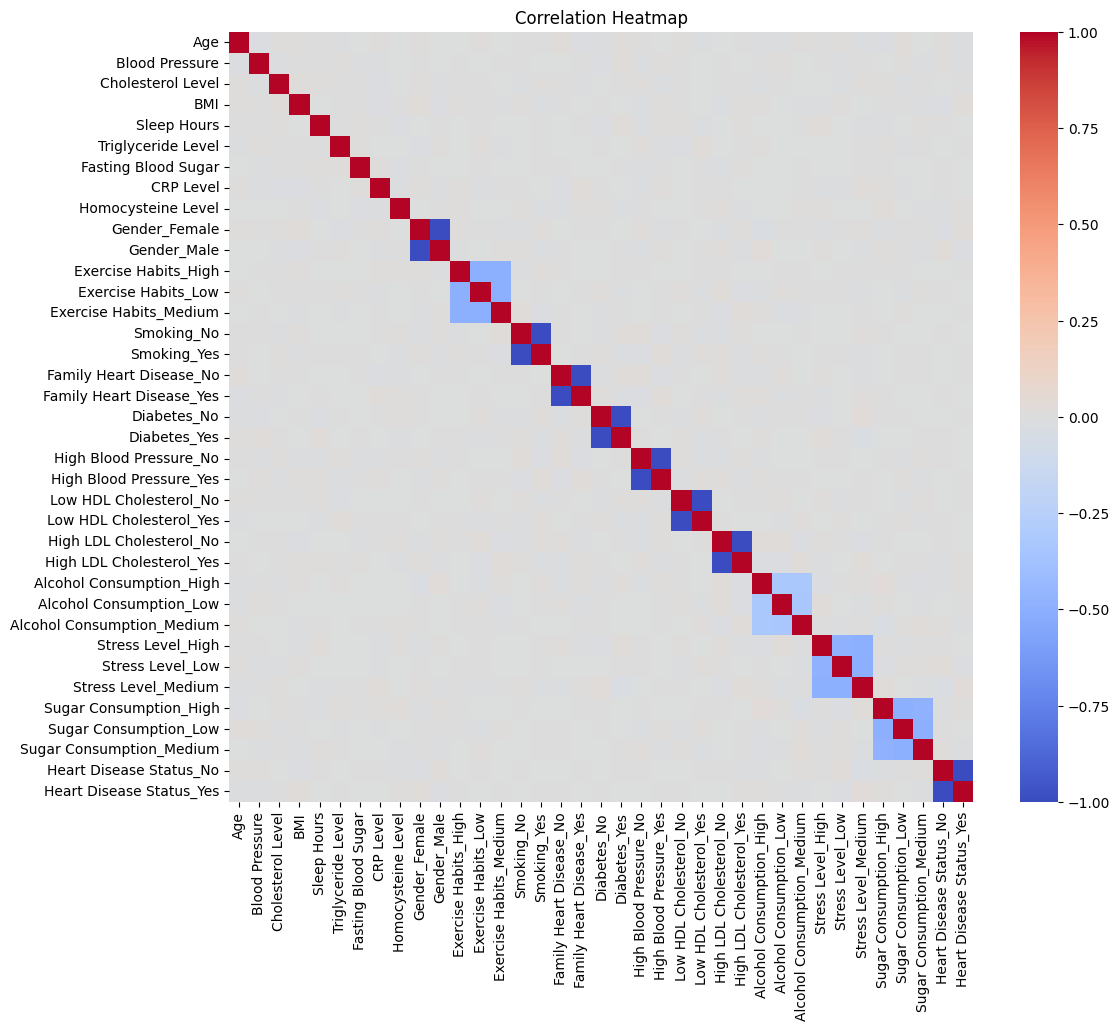

#Train Baseline on Real Data

In [161]:
from sklearn.ensemble import RandomForestClassifier

X_train = pd.get_dummies(train.drop(columns=[target_col], errors="ignore"))
y_train = train[target_col]

X_test = pd.get_dummies(test.drop(columns=[target_col]))
y_test = test[target_col]

model = RandomForestClassifier(
    n_estimators=100,
    random_state=7
)

In [162]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns)

(8000, 35)
(2000, 35)
Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level', 'Gender_Female', 'Gender_Male',
       'Exercise Habits_High', 'Exercise Habits_Low', 'Exercise Habits_Medium',
       'Smoking_No', 'Smoking_Yes', 'Family Heart Disease_No',
       'Family Heart Disease_Yes', 'Diabetes_No', 'Diabetes_Yes',
       'High Blood Pressure_No', 'High Blood Pressure_Yes',
       'Low HDL Cholesterol_No', 'Low HDL Cholesterol_Yes',
       'High LDL Cholesterol_No', 'High LDL Cholesterol_Yes',
       'Alcohol Consumption_High', 'Alcohol Consumption_Low',
       'Alcohol Consumption_Medium', 'Stress Level_High', 'Stress Level_Low',
       'Stress Level_Medium', 'Sugar Consumption_High',
       'Sugar Consumption_Low', 'Sugar Consumption_Medium'],
      dtype='object')


In [163]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=7)

In [164]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.801

0.801